# Klasifikasi Biner Penyakit Jantung dengan Decision Tree

**Dataset:** UCI Heart Disease (Cleveland subset, 303 baris, 13 fitur numerik)
**Model:** Decision Tree Classifier (parameter default, tanpa tuning)
**Tujuan:** Memprediksi apakah seorang pasien memiliki indikasi penyakit jantung (1) atau tidak (0), berdasarkan data medis numerik dasar seperti usia, tekanan darah, kolesterol, dan hasil pemeriksaan jantung lainnya.

Notebook ini sengaja dibuat sederhana:
- Tidak ada feature selection
- Tidak ada scaling/normalisasi (Decision Tree tidak sensitif terhadap skala fitur)
- Preprocessing hanya sebatas pengecekan data kosong, duplikat, dan pembagian data latih/uji

Tujuannya adalah membangun baseline yang mudah dipahami sebelum masuk ke teknik yang lebih kompleks (feature engineering, hyperparameter tuning, ensemble methods, dsb).


## 1. Import Library

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

sns.set_style("whitegrid")


## 2. Load Dataset

Dataset yang digunakan adalah versi UCI Heart Disease (Cleveland) yang sudah diproses menjadi 14 kolom (13 fitur + 1 target), dengan target biner (0 = tidak ada penyakit jantung, 1 = ada indikasi penyakit jantung).

Keterangan singkat fitur:
- `age`: usia pasien
- `sex`: jenis kelamin (1 = laki-laki, 0 = perempuan)
- `cp`: tipe nyeri dada (0-3)
- `trestbps`: tekanan darah saat istirahat (mm Hg)
- `chol`: kadar kolesterol serum (mg/dl)
- `fbs`: gula darah puasa > 120 mg/dl (1 = ya, 0 = tidak)
- `restecg`: hasil elektrokardiografi saat istirahat (0-2)
- `thalach`: detak jantung maksimum yang dicapai
- `exang`: angina akibat olahraga (1 = ya, 0 = tidak)
- `oldpeak`: depresi ST akibat olahraga relatif terhadap istirahat
- `slope`: kemiringan segmen ST puncak saat olahraga (0-2)
- `ca`: jumlah pembuluh darah utama yang terlihat lewat fluoroskopi (0-3)
- `thal`: kondisi thalassemia (1 = normal, 2 = defek tetap, 3 = defek reversibel)
- `target`: 0 = tidak ada penyakit jantung, 1 = ada indikasi penyakit jantung


In [5]:
df = pd.read_csv("heart.csv")
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [6]:
df.shape


(303, 14)

## 3. Preprocessing Dasar

Karena tujuannya membuat baseline sederhana, preprocessing yang dilakukan hanya:
1. Cek tipe data & missing value
2. Cek duplikat data
3. Cek distribusi target (apakah data seimbang atau tidak)
4. Split data menjadi data latih dan data uji

Tidak ada feature selection maupun scaling, karena Decision Tree bekerja berdasarkan pemisahan nilai (threshold split) pada tiap fitur, sehingga tidak terpengaruh oleh skala data yang berbeda-beda.


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [8]:
# Cek missing value
df.isnull().sum()


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [9]:
# Cek duplikat data
print("Jumlah baris duplikat:", df.duplicated().sum())


Jumlah baris duplikat: 1


In [10]:
# Jika ada duplikat, kita hapus agar tidak bias saat evaluasi
df = df.drop_duplicates()
df.shape


(302, 14)

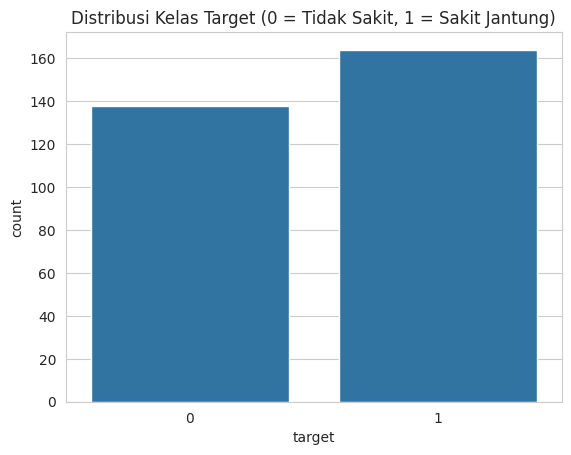

,proportion
target,
1,0.543046
0,0.456954


In [11]:
# Distribusi target
sns.countplot(x="target", data=df)
plt.title("Distribusi Kelas Target (0 = Tidak Sakit, 1 = Sakit Jantung)")
plt.show()

df["target"].value_counts(normalize=True)


## 4. Split Data Latih dan Data Uji

Data dibagi menjadi 80% data latih dan 20% data uji. Parameter `stratify=y` digunakan agar proporsi kelas target di data latih dan data uji tetap seimbang, mengingat distribusi kelas yang tidak 100% sama rata.


In [12]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Data latih:", X_train.shape)
print("Data uji  :", X_test.shape)


Data latih: (241, 13)
Data uji  : (61, 13)


## 5. Training Model Decision Tree

Model dilatih menggunakan parameter default dari `DecisionTreeClassifier` di scikit-learn (tanpa hyperparameter tuning), sesuai tujuan notebook ini sebagai baseline sederhana. `random_state` diset agar hasil dapat direproduksi.


In [13]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

## 6. Evaluasi Model

Metrik yang digunakan:
- **Accuracy** — proporsi prediksi benar secara keseluruhan
- **Precision** — dari semua yang diprediksi positif (sakit jantung), berapa persen yang benar-benar positif
- **Recall** — dari semua yang benar-benar positif, berapa persen yang berhasil terdeteksi model
- **F1-score** — rata-rata harmonik precision dan recall
- **Confusion Matrix** — rincian prediksi benar/salah per kelas

Recall penting diperhatikan pada kasus medis seperti ini, karena kesalahan tipe *false negative* (pasien sakit tapi diprediksi sehat) memiliki risiko lebih besar dibanding *false positive*.


In [14]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")


Accuracy  : 0.7213
Precision : 0.7105
Recall    : 0.8182
F1-score  : 0.7606


In [15]:
print(classification_report(y_test, y_pred, target_names=["Tidak Sakit (0)", "Sakit Jantung (1)"]))


                   precision    recall  f1-score   support

  Tidak Sakit (0)       0.74      0.61      0.67        28
Sakit Jantung (1)       0.71      0.82      0.76        33

         accuracy                           0.72        61
        macro avg       0.72      0.71      0.71        61
     weighted avg       0.72      0.72      0.72        61



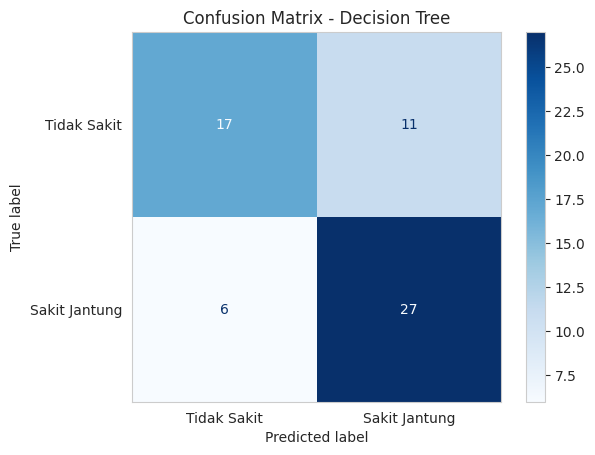

In [33]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Tidak Sakit", "Sakit Jantung"])
disp.plot(cmap="Blues")
plt.grid(False)
plt.title("Confusion Matrix - Decision Tree")
plt.show()


## 7. Feature Importance

Walaupun tidak melakukan feature selection di awal, kita tetap bisa melihat fitur mana yang paling berpengaruh menurut model setelah training selesai. Ini berguna sebagai bahan analisis lanjutan, bukan bagian dari preprocessing.


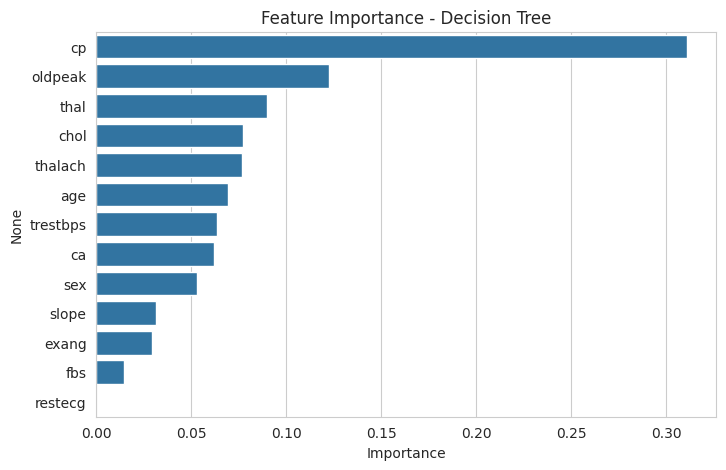

,0
cp,0.310925
oldpeak,0.122348
thal,0.089707
chol,0.077418
thalach,0.076846
age,0.069430
trestbps,0.063551
ca,0.061908
sex,0.052780
slope,0.031670


In [17]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance - Decision Tree")
plt.xlabel("Importance")
plt.show()

importances


## 8. Visualisasi Struktur Decision Tree

Salah satu kelebihan Decision Tree adalah interpretabilitasnya — kita bisa melihat langsung aturan keputusan yang dipelajari model. Karena pohon tanpa batas kedalaman (default) bisa sangat besar, visualisasi berikut dibatasi hingga kedalaman 3 saja agar mudah dibaca.


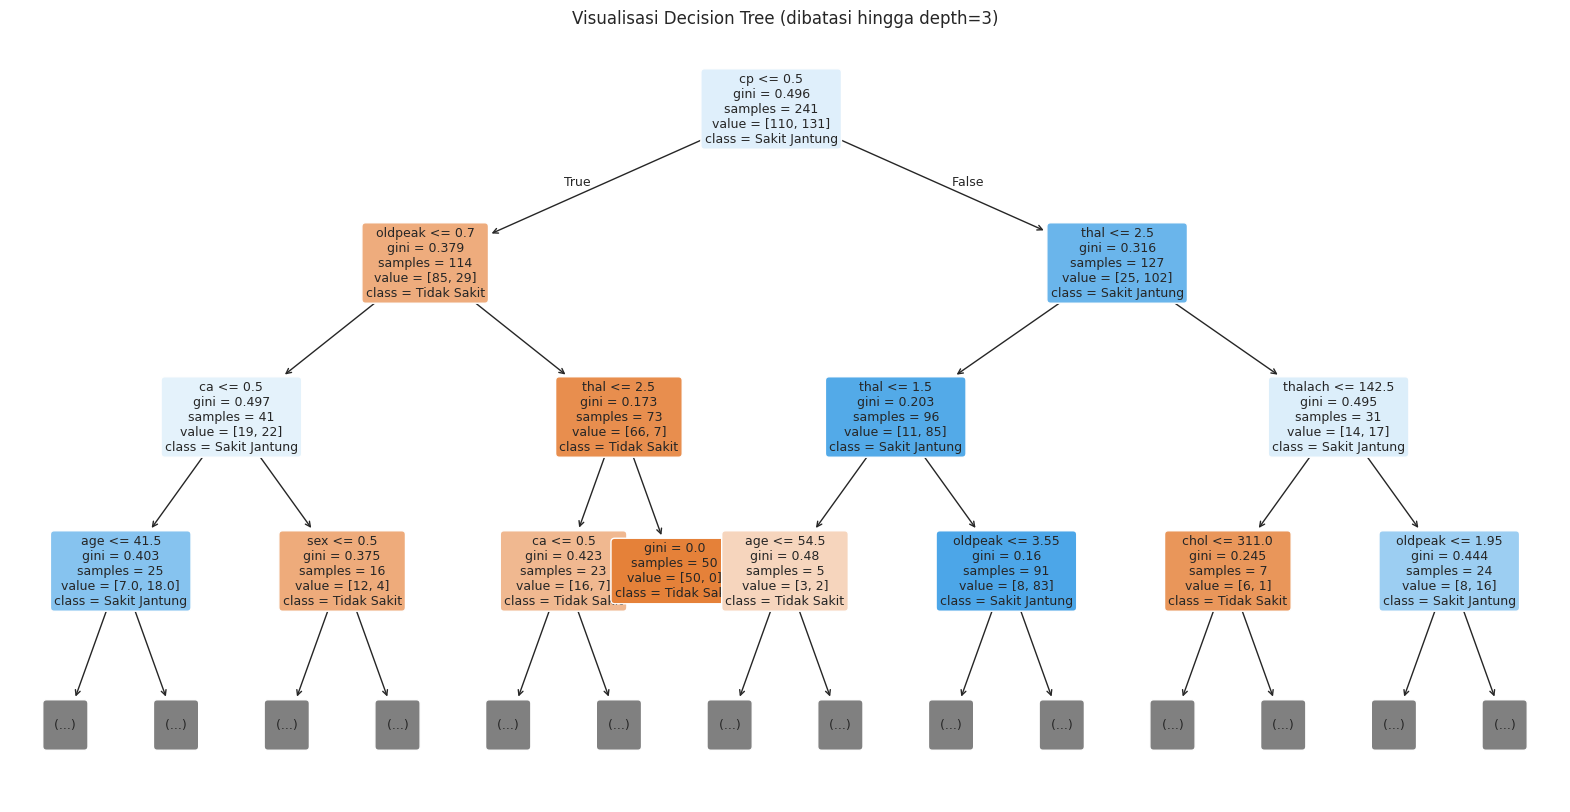

In [20]:
plt.figure(figsize=(20, 10))
plot_tree(
    model,
    max_depth=3,
    feature_names=X.columns,
    class_names=["Tidak Sakit", "Sakit Jantung"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Visualisasi Decision Tree (dibatasi hingga depth=3)")
plt.show()


## 9. Kesimpulan & Keterbatasan

**Ringkasan hasil:**
Model Decision Tree dengan parameter default mampu mengklasifikasikan data uji dengan hasil yang tercantum pada bagian evaluasi di atas. Fitur seperti `cp` (tipe nyeri dada), `thalach` (detak jantung maksimum), dan `ca` (jumlah pembuluh darah yang terdeteksi) umumnya menjadi fitur dengan kontribusi tinggi terhadap keputusan model.

**Keterbatasan pendekatan ini:**
- Tanpa hyperparameter tuning (`max_depth`, `min_samples_split`, dsb), Decision Tree cenderung *overfitting* terhadap data latih.
- Tanpa cross-validation, evaluasi hanya bergantung pada satu kali pembagian data latih/uji sehingga hasil bisa bervariasi tergantung `random_state`.
- Ukuran dataset relatif kecil (303 baris), sehingga generalisasi ke populasi yang lebih luas perlu divalidasi lebih lanjut.

**Rencana pengembangan lanjutan:**
- Melakukan hyperparameter tuning (GridSearchCV) untuk mengurangi overfitting
- Membandingkan performa dengan model lain (Random Forest, Logistic Regression, SVM)
- Menerapkan cross-validation untuk evaluasi yang lebih stabil
- Analisis lebih lanjut terhadap fitur dengan importance tinggi (feature engineering)
